<a href="https://colab.research.google.com/github/cosmicurvy/amazon-reviews-nlp/blob/main/notebooks/TopicModeling_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install gensim

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk # to preprocess text data
import re
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer # to convert text into numbers
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.decomposition import LatentDirichletAllocation # for topic modeling
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
dataset_path = '/content/drive/MyDrive/Sentiment-Classification/Musical_Instruments.jsonl.gz'
data = pd.read_json(dataset_path, lines=True, compression='gzip')

In [5]:
data.sample(3)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
1851381,5,"There's no bypass mode, it's always on.",Sounds incredible. The manual mode is easy to ...,[],B07DPXG4FP,B07DPXG4FP,AEJ4WDSMO7ZIDY72IQENZHNQ7KBQ,2019-02-16 04:41:56.340,0,True
546057,5,Perfect balance and fit,These were what my friends needed,[],B00OABYDHG,B00OABYDHG,AGISM63HUTJHBHXNCTC633F3JOKA,2019-07-24 15:31:52.435,0,True
1158195,5,Great sounding plug and play mic.,This thing was so easy to use out of the box. ...,[{'small_image_url': 'https://images-na.ssl-im...,B07WLWN2ZT,B0BWQ92ZPY,AFD5FBXC54RONVRWVC6XXUVJFS5A,2020-07-30 04:10:09.687,0,True


In [6]:
# extract the required features
data = data[['title','text','rating']]

In [7]:
data.shape

(3017439, 3)

In [8]:
print("Total Duplicate Values: ", data.duplicated().sum())

Total Duplicate Values:  179889


In [9]:
# drop duplicate values
data = data.drop_duplicates()
data.shape

(2837550, 3)

- The dataset is very large, so we use a sample of 50,000 data points.

In [10]:
data = data.sample(50000, random_state = 35)
data.shape

(50000, 3)

In [11]:
sample_data_path = '/content/drive/MyDrive/Sentiment-Classification/'

# save the  sample Dataset
data.to_csv(sample_data_path+'amazon_reviews.csv', index=False)

In [12]:
df = pd.read_csv("/content/drive/MyDrive/Sentiment-Classification/amazon_reviews.csv")
df.sample(5)

,title,text,rating
10728,Not well put together.,Once I finally worked out how to get it to wor...,1
43322,Nice sound but some buzzing on the low E string,This guitar is smaller and easier on the finge...,4
47445,"Very durable, very efficient","Simply put, this product does exactly what it ...",5
5210,95% good quality,It’s really sounds good I love this guitar,5
46550,As Described,Looks great and does not come loose!,5


In [13]:
df.shape

(50000, 3)

In [14]:
df.isna().sum()

,0
title,6
text,5
rating,0


In [15]:
df.dropna(inplace=True)

In [16]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
rating,49989.0,4.22619,1.295281,1.0,4.0,5.0,5.0,5.0


### EDA

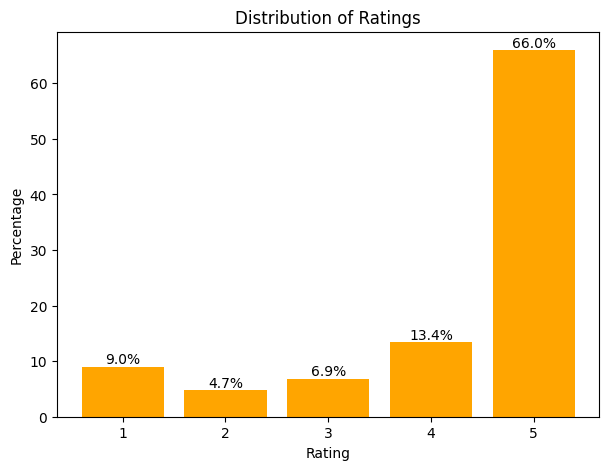

In [17]:
# visualize the distribution of ratings
categories = df.rating.value_counts(normalize=True).index
percentages = df.rating.value_counts(normalize=True).values * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(categories, percentages, color='orange')
plt.bar_label(bars, fmt='%.1f%%')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Percentage")
plt.show()

- Most products received a 5‑star rating, indicating that the majority of reviews are positive. This shows a significant class imbalance in the data.

In [18]:
df['length'] = df['text'].apply(lambda x: len(x))

In [19]:
# function to get the sentiment for each review
def get_sentiment(rate):
  if rate in [1, 2]:
    return 'Negative'
  elif rate == 3:
    return "Neutral"
  else:
    return "Positive"

df['sentiment'] = df['rating'].apply(get_sentiment)

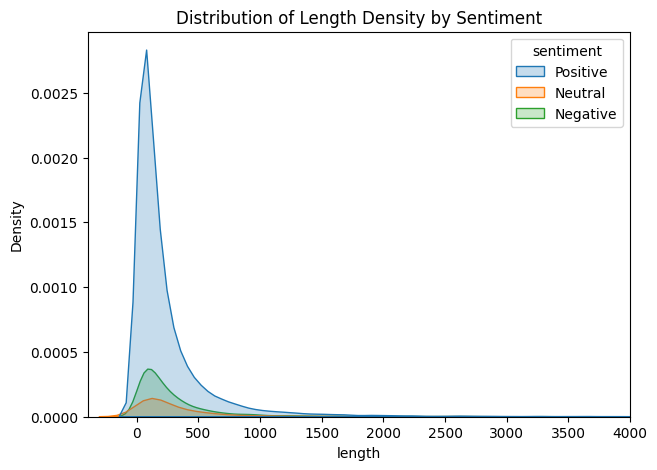

In [20]:
# visualize the reviews length density per sentiment
plt.figure(figsize=(7,5))
sns.kdeplot(data=df, x= 'length', hue='sentiment', fill=True)

plt.title("Distribution of Length Density by Sentiment")
plt.xlim(-400, 4000)
plt.show()

### Text Preprocessing

- Before performing topic modeling, we preprocess the reviews.


In [21]:
lemmatizer = WordNetLemmatizer()
stop_words = stopwords.words('english')

# function to clean the text
def preprocess_txt(text):
  text = text.lower()
  cleaned = re.sub(r'(<br\s*/?>)+', ' ', text)
  cleaned = re.sub(r'[^a-zA-Z0-9]', ' ', cleaned)
  tokens = word_tokenize(cleaned)
  cleaned_tokens = [lemmatizer.lemmatize(token) for token in tokens if not token in stop_words]
  cleaned_txt = ' '.join(cleaned_tokens)
  return cleaned_txt

df['preprocessed_text'] = df['text'].apply(lambda x: preprocess_txt(x))

In [22]:
df.head(3)

,title,text,rating,length,sentiment,preprocessed_text
0,BEST protection for many equipment needs!,I purchased the SKB mid-sized hardware case af...,5,777,Positive,purchased skb mid sized hardware case trying s...
1,Good value,"Well made, good fit & finish, does the job! I...",5,136,Positive,well made good fit finish job want spend money...
2,Nice for gaming,Sound quality is very good for gaming and onli...,5,56,Positive,sound quality good gaming online class


### Topic Modeling

- We perform topic modeling only on negative reviews to group different kinds of issues or complaints the users are facing.

In [23]:
# filter negative reviews
data_tm = df[df['sentiment'] == 'Negative']

In [24]:
data_tm.shape

(6874, 6)

In [25]:
# stop words for countvectorizer
overlapping_noise = ['product', 'work', 'worked', 'working', 'stopped', 'like', 'even', 'use', 'back', 'got', 'time',
                     'first', 'item', 'came', 'didnt', 'doesnt', 'one', 'get', 'would', 'really', 'much', 'using',
                     'way', 'good', 'great', 'bad', 'buy', 'bought', 'quality', '34']

- We apply Bag-of-Words (BoW) model via CountVectorizer to convert unstructured text into numerical feature.

- During topic modeling, we notice significant word overlap between topics, so we pass those words to the stop_words in the CountVectorizer to reduce redundancy.

In [26]:
# initialize the vectorizer
vectorizer = CountVectorizer(stop_words= overlapping_noise, lowercase=False, max_df=0.75, min_df=5)
doc_matrix = vectorizer.fit_transform(data_tm['preprocessed_text']) # fit on negative reviwews
feature_names = vectorizer.get_feature_names_out()

In [27]:
#LDA
lda_model = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=15)
lda_model.fit(doc_matrix)

LatentDirichletAllocation(max_iter=15, n_components=5, random_state=42)

In [28]:
# extract top 15 words per topic
topics = []

for topic in lda_model.components_:
  top_words = [feature_names[i] for i in topic.argsort()[-15:][::-1]]
  topics.append(top_words)

In [29]:
analyzer = vectorizer.build_analyzer()

# this ensures gensim evaluates the exact same token scikit-learn processed
cleaned_tokens = [analyzer(doc) for doc in data_tm['preprocessed_text']]

In [30]:
# create a dictionary
gensim_dict = Dictionary(cleaned_tokens)

- We use the Coherence score to evaluate the LDA topics, it measures how clear (semantically meaningful) the topics are.

In [31]:
# initialize the coherence model
coherence_model = CoherenceModel(topics= topics, texts = cleaned_tokens, dictionary= gensim_dict,  coherence='c_v')

print("Coherence Score: ", coherence_model.get_coherence())

Coherence Score:  0.5433963485253714


In [32]:
for topic in topics:
  print(topic)

['return', 'month', 'day', 'broke', 'amazon', 'week', 'year', 'received', 'never', 'new', 'light', 'used', 'replacement', 'two', 'customer']
['cable', 'pedal', 'power', 'device', 'bag', 'usb', 'plug', 'also', 'thing', 'mic', 'headphone', 'need', 'keyboard', 'sound', 'used']
['guitar', 'string', 'play', 'instrument', 'sound', 'tune', 'playing', 'tuner', 'neck', 'made', 'look', 'better', 'well', 'strap', 'pick']
['sound', 'mic', 'speaker', 'amp', 'noise', 'volume', 'money', 'microphone', 'better', 'make', 'audio', 'unit', 'loud', 'something', 'hear']
['stand', 'fit', 'cheap', 'plastic', 'hold', 'screw', 'part', 'piece', 'mic', 'made', 'arm', 'metal', 'look', 'hole', 'small']


In [37]:
topic0 = "return, month, day, broke, amazon, week, year, received, never, new, light, used, replacement, two, customer"
topic1 = "cable, pedal, power, device, bag, usb, plug, also, thing, mic, headphone, need, keyboard, sound, used"
topic2 = "guitar, string, play, instrument, sound, tune, playing, tuner, neck, made, look, better, well, strap, pick"
topic3 = "sound, mic, speaker, amp, noise, volume, money, microphone, better, make, audio, unit, loud, something, hear"
topic4 = "stand, fit, cheap, plastic, hold, screw, part, piece, mic, made, arm, metal, look, hole, small"

In [34]:
# function for  word cloud
def generate_wordcloud(words, topic, ax):
  wc = WordCloud(width=1000,height=700, background_color='black').generate(words)
  ax.set_title(f"{topic}")
  ax.imshow(wc)
  ax.axis('off')

### WordCloud

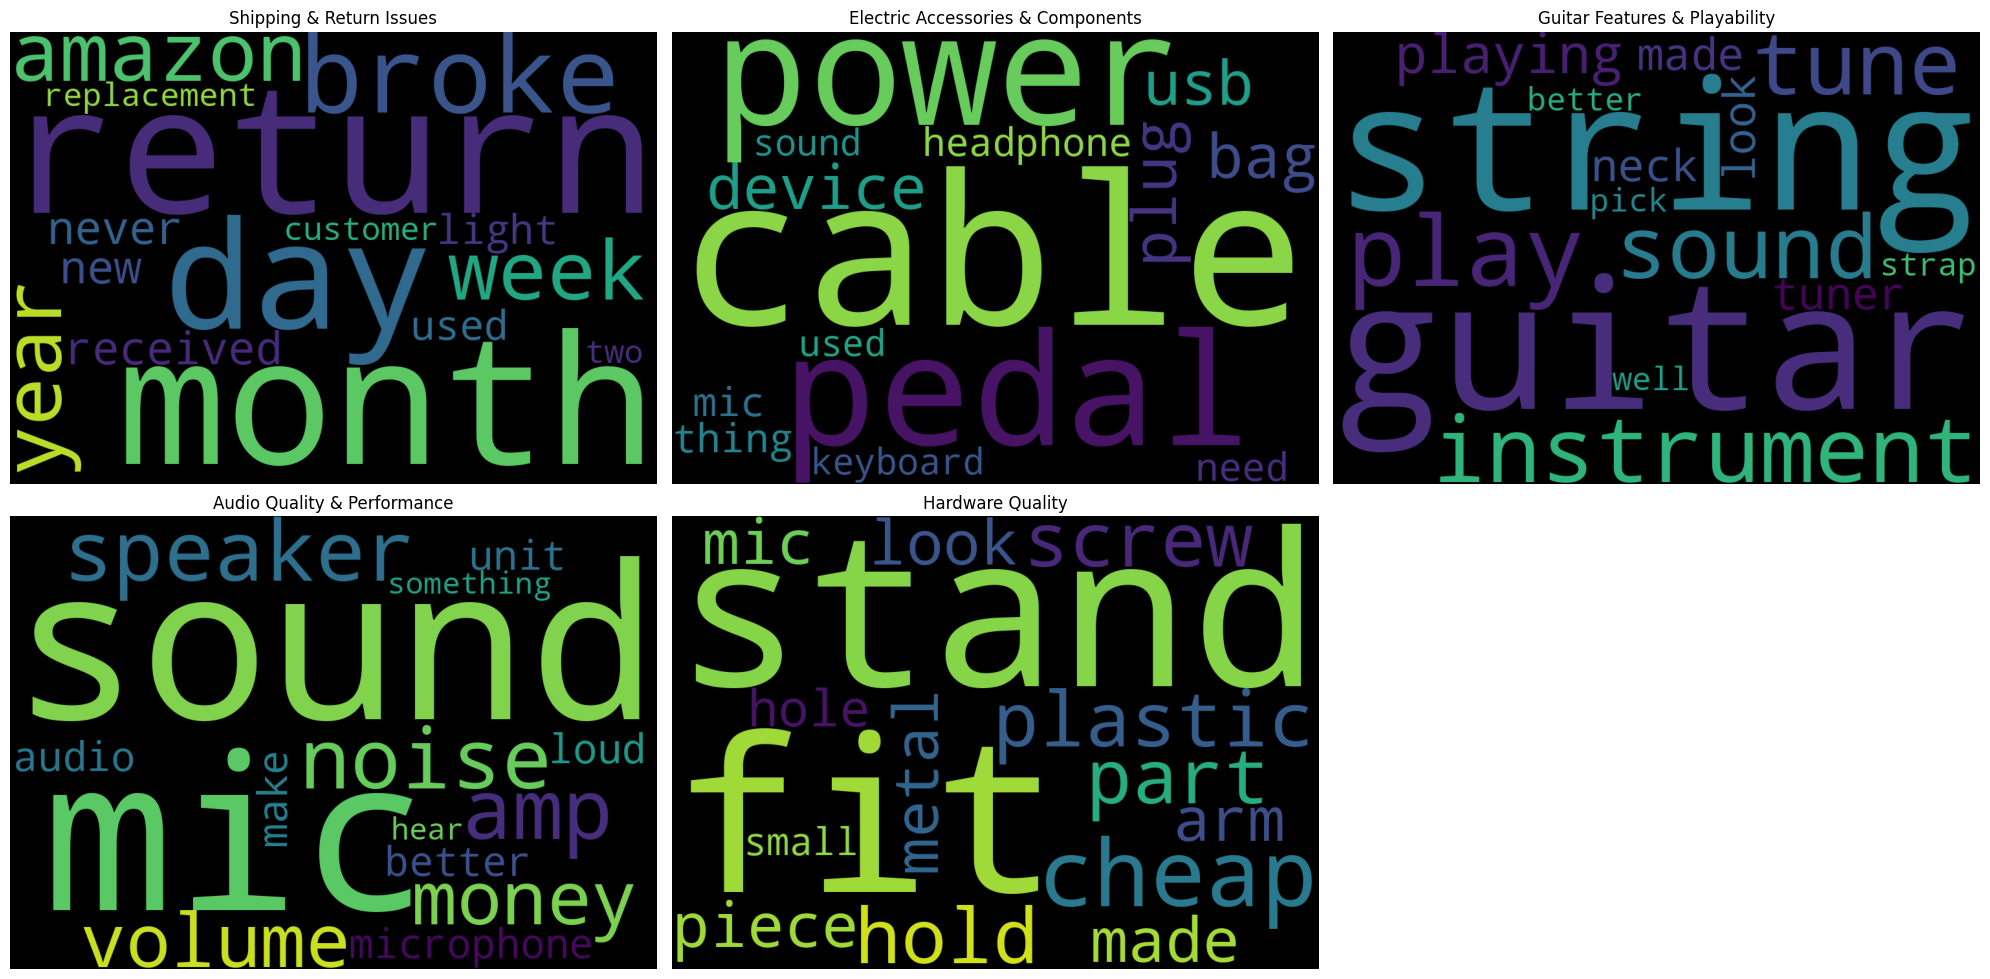

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(20,10))
axes = axes.flatten()

generate_wordcloud(words= topic0, topic="Shipping & Return Issues", ax= axes[0])
generate_wordcloud(words= topic1, topic="Electric Accessories & Components", ax= axes[1])
generate_wordcloud(words= topic2, topic="Guitar Features & Playability", ax= axes[2])
generate_wordcloud(words= topic3, topic="Audio Quality & Performance", ax= axes[3])
generate_wordcloud(words= topic4, topic="Hardware Quality", ax= axes[4])

axes[5].set_visible(False)

plt.tight_layout()
plt.show()

In [39]:
# get the topic probabilities
topic_probabilities = lda_model.transform(doc_matrix)
topic_names = {0: 'Shipping & Return Issues', 1: 'Electric Accessories & Components', 2: 'Guitar Features & Playability', 3: 'Audio Quality & Performance', 4: 'Hardware Quality'}

# create new columns
data_tm['topic'] = topic_probabilities.argmax(axis=1)
data_tm['topic_probs'] = topic_probabilities.max(axis=1)
data_tm['topic_name'] = data_tm['topic'].map(topic_names)

In [40]:
data_tm.sample(3)

,title,text,rating,length,sentiment,preprocessed_text,topic,topic_probs,topic_name
20222,Bought in 2015 new off Amazon. 2 years later ...,Bought in 2015 new off Amazon. 2 years later i...,1,776,Negative,bought 2015 new amazon 2 year later stopped wo...,0,0.443373,Shipping & Return Issues
30971,"Great Idea, Poor Execution",When I got this item I was excited at the poss...,2,1062,Negative,got item excited possibility using ipad garage...,4,0.429044,Hardware Quality
16308,Read before buying,I bought this product locally from Elderly Ins...,1,477,Negative,bought product locally elderly instrument work...,2,0.971487,Guitar Features & Playability


In [41]:
# extract top 5 reviews for each topic
top_reviews = pd.DataFrame()

for topic_id in topic_names.keys():
  top_5 = data_tm[data_tm['topic']== topic_id].sort_values(by='topic_probs', ascending=False).head(5)
  top_reviews = pd.concat([top_reviews, top_5])

- To make the model results easier to interpret, we show the original raw review text for each topic rather than the preprocessed text.

In [42]:
print("Top 5 Reviews of Topic 0 (Shipping & Return Issues) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[:5, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 0 (Shipping & Return Issues) -->


1) I successfully installed this program, but to run it you need to "activate" it - enter your name, the serial number, your email address and ...
2) we purchased this machine to use as special effects with photography. We tested it out when it was first received and it worked fine.  Clean...
3) I will update my review to say that it has now been three weeks since I contacted 1byone's customer service and I still have not heard from ...
4) I originally purchased this item 2 day air.  After 7 days I contacted Amazon and they basically told me that that happens some times.  They ...
5) I like this light a lot, but it needs constant recharging.  I've had it for a while, and a full charge (based on the light display on the un...


In [43]:
print("Top 5 Reviews of Topic 1 (Electric Accessories & Components) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[5:10, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 1 (Electric Accessories & Components) -->


1) I bought this to act as footswitch 4 and footswitch 5 on my HX Stomp like a few other people have done. I have tried with three different TR...
2) The chip was sent inside an anti-static bag.  No instructions or paperwork of any kind was included.  No markings on the chip at all...not t...
3) The picture of this product shows SILVER charms but I received GOLD charms... as it seems others did in looking at these videos posted.  ???...
4) The USB port on the back of the mic that I received is NOT the type shown in the picture. THIS IS IMPORTANT, PEOPLE. I ordered this along wi...
5) When I plug the controller into my computer, with or without DJUCED software open, my pc says "USB device malfunctioned and is not recognize...


In [44]:
print("Top 5 Reviews of Topic 2 (Guitar Features & Playability) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[10:15, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 2 (Guitar Features & Playability) -->


1) Update 8/17/2021:  at first this ukulele was not bad after doing a set up. As time went on the neck began to bow… and bow… and bow.  There w...
2) Absolutely beautiful finish but chromatically way out of tune to the point I could not even play it. It literally hurt my ears.<br />Turns o...
3) I'm a guitar builder, guitarist, bassist, and ukelele player.  I also teach guitar to children and adults.<br /><br />I was really disappoin...
4) In short, it's too small. I have two guitars - a Squier Strat and an Epiphone SG400. I measured them both from the rear strap button to the ...
5) I was skeptical about some of the reviews for this guitar. Issues with tuning and string tension are quite normal for new guitars (incl. exp...


In [45]:
print("Top 5 Reviews of Topic 3 (Audio Quality & Performance) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[15:20, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 3 (Audio Quality & Performance) -->


1) The Hartke LH500 was severely lacking in the power output and tone quality that I was expecting for the price, especially in the lower regis...
2) My recommendation to you, is before purchasing this product, or a product like it, try it before you buy it 100% of the time.  Take your tim...
3) When I installed this amplifier, I ran it with a 10” JL Audio W0 at 4 ohms.  It sounded great for all of 5 minutes before the safety tripped...
4) Well for starters, this mic was a decent microphone. It will never compare to a top quality condenser microphone, but it has its place. The ...
5) Initially this microphone worked fine I’ll give it having some problems with sound quality .it was a tad too quiet. I had to turn the output...


In [46]:
print("Top 5 Reviews of Topic 4 (Hardware Quality) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[20:, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 4 (Hardware Quality) -->


1) Mount is much smaller than I expected. The mount I got does not look like the on in the picture. What I revived is not at all what was descr...
2) I bought the 1 1/2&#34; bells, they were pretty, well proportioned but a little small. I kept them and braided them into a cord and thought ...
3) Mine failed in 2 ways:<br /><br />The first problem - the bottom of the main Center Column is merely crimped against the Threaded Bolt that ...
4) To be honest.  it was cracked on the top screw in that holds the mic bar to the stand, when I bought it.  You spend cheap, you get cheap and...
5) What gives?  I have a Shure SM58 microphone so I bought this Shure A25D holder that clearly states it is for a Shure SM58.  But the micropho...


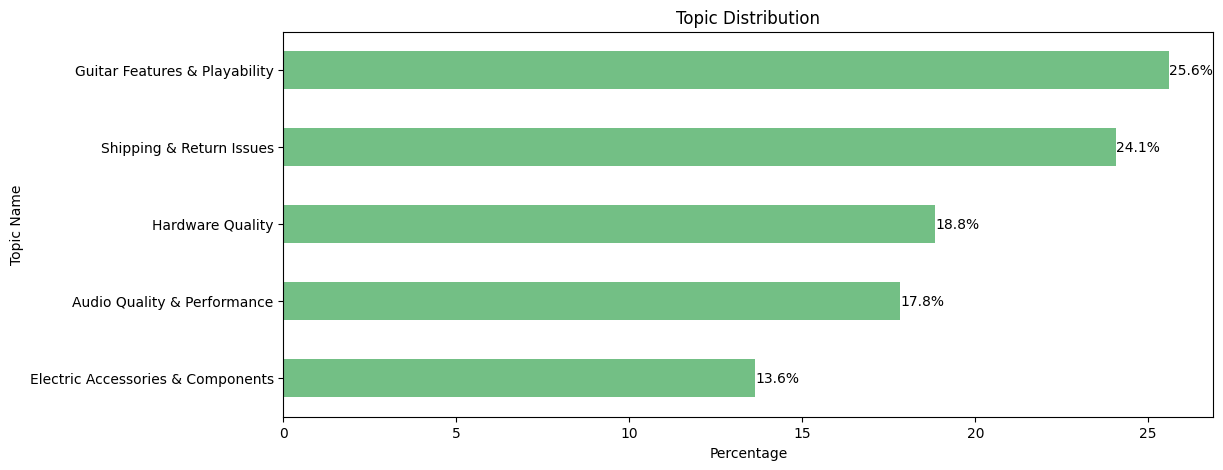

In [47]:
# visualize the topic distribution
plt.figure(figsize= (12,5))

ax = (data_tm['topic_name'].value_counts(normalize=True) * 100).sort_values().plot(kind='barh', color='#73bf85')
for container in ax.containers:
  ax.bar_label(container, fmt='%.1f%%')

plt.title("Topic Distribution")
plt.xlabel('Percentage')
plt.ylabel("Topic Name")
plt.show()

- Most of the reviews fall under the `Guitar Features & Playability` (Topic 2), followed by `Shipping & Return Issues` (Topic 0) and `Hardware Quality` (Topic 4).

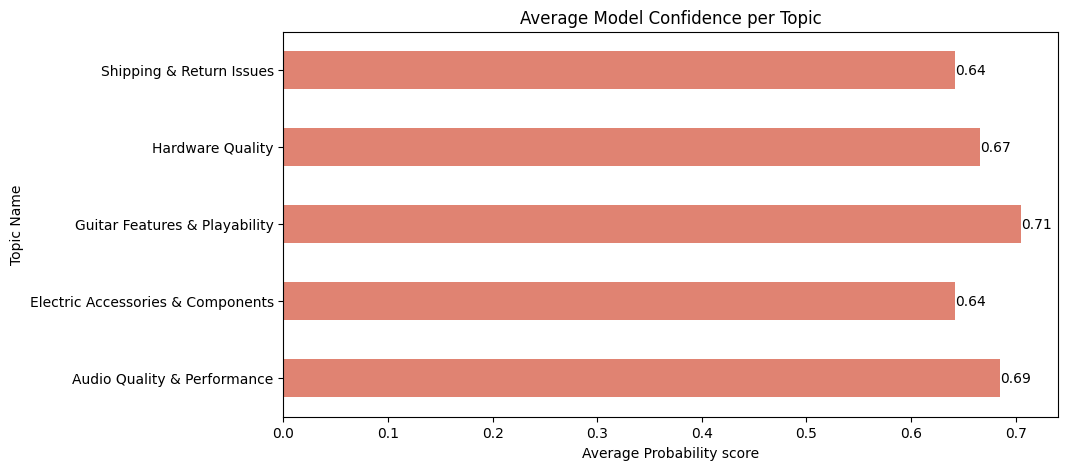

In [48]:
# visualize the average model confidence
plt.figure(figsize= (10,5))
ax = data_tm.groupby('topic_name')['topic_probs'].mean().plot(kind='barh', color='#e08372')

for container in ax.containers:
  ax.bar_label(container, fmt= '%.2f')

plt.title("Average Model Confidence per Topic")
plt.xlabel('Average Probability score')
plt.ylabel("Topic Name")
plt.show()

- Average probability score is higher for `Guitar Features & Playability` topic, followed by `Audio Quality & Performance` topic and `Hardware Quality` topic.